## Part (c) — Simulation of the German Tank Problem

We now simulate the estimators:
$$
\hat{M}_{\text{MLE}} = x_{(n)}, \qquad
\hat{M}_{\text{MEAN}} = 2\bar{x} - 1, \qquad
\hat{M}_{\text{MVU}} = x_{(n)}\left(\frac{n+1}{n}\right) - 1
$$
for various true values of \(M\) and sample sizes \(n\).

For each pair \((M, n)\), we:
1. Repeatedly draw \(n\) samples uniformly from \(\{1, 2, \dots, M\}\),
2. Compute each estimator,
3. Calculate the empirical mean and variance of the estimators over many simulations.

This allows us to observe the bias and variance tradeoffs as \(n\) increases and \(M\) varies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

def simulate_tank_problem(M, n, reps=5000):
    """Simulate the German Tank problem for given M, n."""
    mle, mean_est, mvu = [], [], []

    for _ in range(reps):
        sample = np.random.randint(1, M + 1, size=n)
        x_max = np.max(sample)
        x_bar = np.mean(sample)

        mle.append(x_max)
        mean_est.append(2 * x_bar - 1)
        mvu.append(x_max * (n + 1) / n - 1)

    return {
        "MLE": np.array(mle),
        "MEAN": np.array(mean_est),
        "MVU": np.array(mvu)
    }

# parameters
M_values = [100, 1000, 10000]
n_values = [5, 10, 20, 50, 100, 200]

# storage for mean and variance
results = {M: {"n": [], "mean": {}, "var": {}} for M in M_values}

for M in M_values:
    means, vars_ = {}, {}
    for est in ["MLE", "MEAN", "MVU"]:
        means[est], vars_[est] = [], []

    for n in n_values:
        sims = simulate_tank_problem(M, n)
        for est in sims:
            means[est].append(np.mean(sims[est]))
            vars_[est].append(np.var(sims[est]))
    results[M]["mean"] = means
    results[M]["var"] = vars_
    results[M]["n"] = n_values


### Visualization — Mean and Variance of Estimators

We now plot the empirical mean and variance of the estimators as functions of $n$ for different true $M$ values

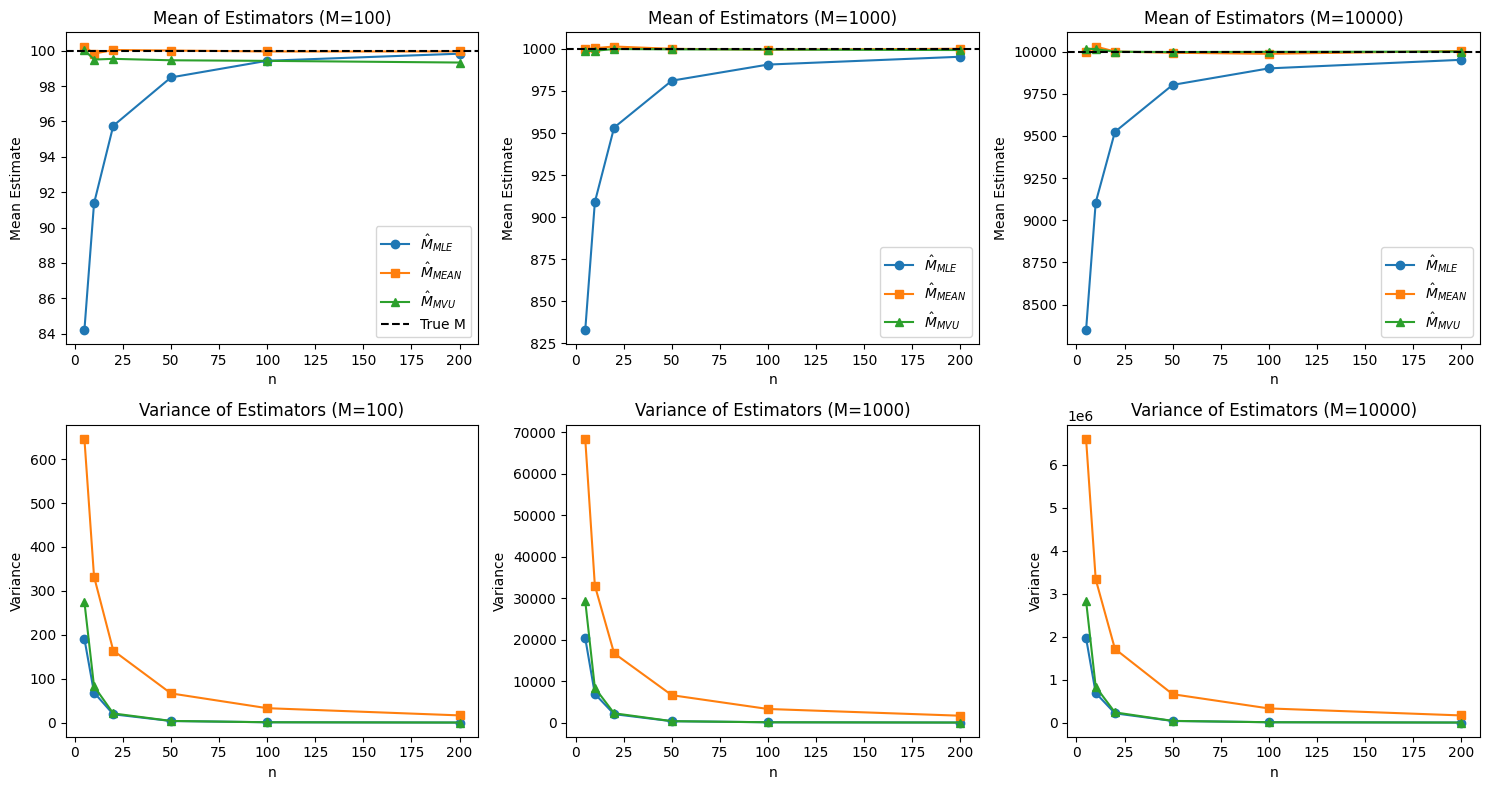

In [3]:
fig, axes = plt.subplots(2, len(M_values), figsize=(15, 8))

for i, M in enumerate(M_values):
    n = results[M]["n"]
    means = results[M]["mean"]
    vars_ = results[M]["var"]

    # --- Mean plot ---
    axes[0, i].plot(n, means["MLE"], 'o-', label=r'$\hat{M}_{MLE}$')
    axes[0, i].plot(n, means["MEAN"], 's-', label=r'$\hat{M}_{MEAN}$')
    axes[0, i].plot(n, means["MVU"], '^-', label=r'$\hat{M}_{MVU}$')
    axes[0, i].axhline(M, color='black', linestyle='--', label='True M' if i == 0 else "")
    axes[0, i].set_title(f"Mean of Estimators (M={M})")
    axes[0, i].set_xlabel("n")
    axes[0, i].set_ylabel("Mean Estimate")
    axes[0, i].legend()

    # --- Variance plot ---
    axes[1, i].plot(n, vars_["MLE"], 'o-', label=r'$\hat{M}_{MLE}$')
    axes[1, i].plot(n, vars_["MEAN"], 's-', label=r'$\hat{M}_{MEAN}$')
    axes[1, i].plot(n, vars_["MVU"], '^-', label=r'$\hat{M}_{MVU}$')
    axes[1, i].set_title(f"Variance of Estimators (M={M})")
    axes[1, i].set_xlabel("n")
    axes[1, i].set_ylabel("Variance")

plt.tight_layout()
plt.show()

### Discussion

- **Bias:**  
  The MLE estimator $\hat{M}_{MLE}$ is biased downward for small $n$, since $E[\hat{M}_{MLE}] = \frac{n}{n+1}(M+1) < M$.  
  As $n$ increases, the bias decreases and the estimator becomes approximately unbiased.  
  Both $\hat{M}_{MEAN}$ and $\hat{M}_{MVU}$ are unbiased for all $n$.

- **Variance:**  
  The variance of all estimators decreases with increasing $n$, but $\hat{M}_{MVU}$ consistently shows the **lowest variance**, confirming its efficiency.  
  The $\hat{M}_{MEAN}$ estimator performs similarly in bias but has slightly higher variance, while $\hat{M}_{MLE}$ exhibits both bias and higher spread for small samples.

- **Effect of $M$:**  
  As $M$ increases, the absolute variance scales roughly with $M^2$, but the relative behavior of estimators remains consistent across all scales.